# Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split




In [3]:
import sys
sys.path.append('..')
from src.evaluation import evaluate

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_csv('../data/bank-additional-full.csv', sep=';')
print(df.shape)
df.head()



(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Exploratory data analysis

## 1. Dataset structure 

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

## 2. Target distribution 

In [7]:

df['y'].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

In [8]:
cat_cols = df.select_dtypes(include='object').columns

/var/folders/dt/v_rjt_mx4k1g8dyxbm2gw8140000gn/T/ipykernel_62325/2176772794.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


## 3. Masked missing values ('unknown') in categorical columns


In [9]:
for col in cat_cols:
    share = (df[col] == 'unknown').mean()
    if share > 0:
        print(f'{col}: {share:.3f}')

job: 0.008
marital: 0.002
education: 0.042
default: 0.209
housing: 0.024
loan: 0.024


## 4. Temporal structure of the data




<Axes: >

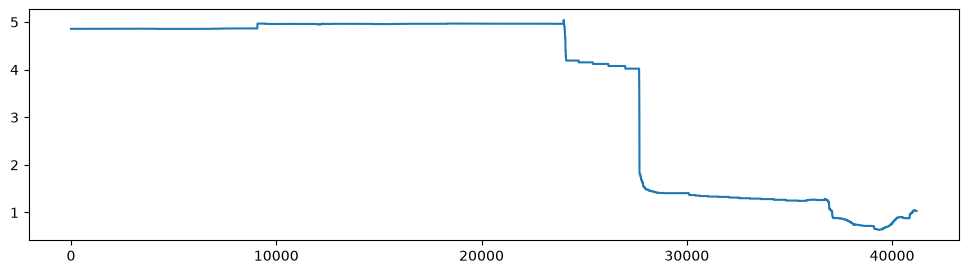

In [10]:
df['euribor3m'].plot(figsize=(12, 3))

## 5. Conversion over time


<Axes: >

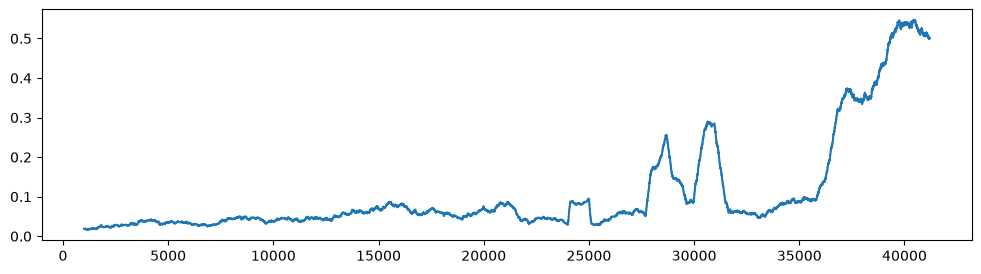

In [11]:
df['y_bin'] = (df['y'] == 'yes').astype(int)
df['y_bin'].rolling(1000).mean().plot(figsize=(12, 3))

## 6. Monthly conversion rate


In [12]:
df.groupby('month')['y_bin'].agg(['mean', 'count'])


,mean,count
month,,
apr,0.204787,2632
aug,0.106021,6178
dec,0.489011,182
jul,0.090466,7174
jun,0.105115,5318
mar,0.505495,546
may,0.064347,13769
nov,0.101439,4101
oct,0.438719,718


## 7. Previous contact history


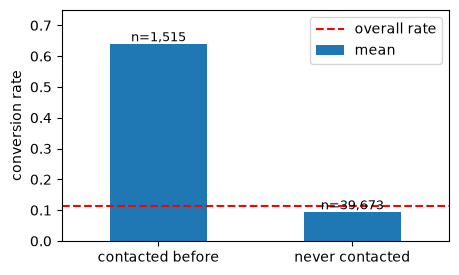

In [13]:
# Conversion: previously contacted vs not.
never_contacted = (df['pdays'] == 999)

stats = df.groupby(never_contacted)['y_bin'].agg(['mean', 'count'])
stats.index = ['contacted before', 'never contacted']

ax = stats['mean'].plot(kind='bar', figsize=(5, 3), rot=0)

for i, (m, n) in enumerate(zip(stats['mean'], stats['count'])):
    ax.text(i, m + 0.01, f'n={n:,}', ha='center', fontsize=9)

plt.axhline(df['y_bin'].mean(), color='red', linestyle='--', label='overall rate')
plt.ylabel('conversion rate')
plt.ylim(0, 0.75)
plt.legend()
plt.show()



In [14]:
# 999 is a sentinel, not a duration. Split the column into a flag and a real distance.

df['was_contacted_before'] = (df['pdays'] != 999).astype(int)
df['pdays_clean'] = df['pdays'].where(df['pdays'] != 999, -1)

## 8. Outcome of the previous campaign


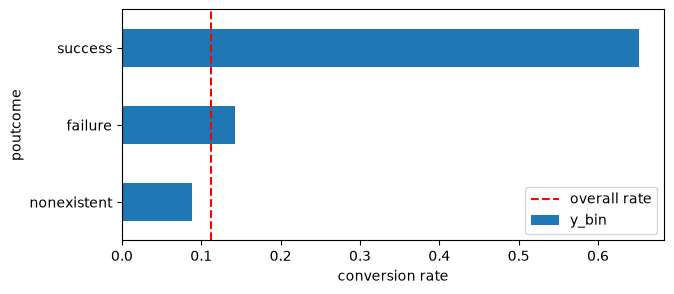

In [15]:
conv = df.groupby('poutcome')['y_bin'].mean().sort_values()

conv.plot(kind='barh', figsize=(7, 3))
plt.axvline(df['y_bin'].mean(), color='red', linestyle='--', label='overall rate')
plt.xlabel('conversion rate')
plt.legend()
plt.show()

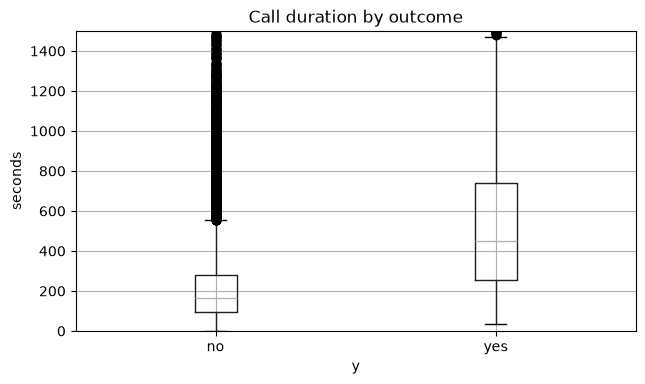

In [16]:
# Duration distribution by outcome.

df.boxplot(column='duration', by='y', figsize=(7, 4))
plt.ylim(0, 1500)
plt.suptitle('')
plt.title('Call duration by outcome')
plt.ylabel('seconds')
plt.show()



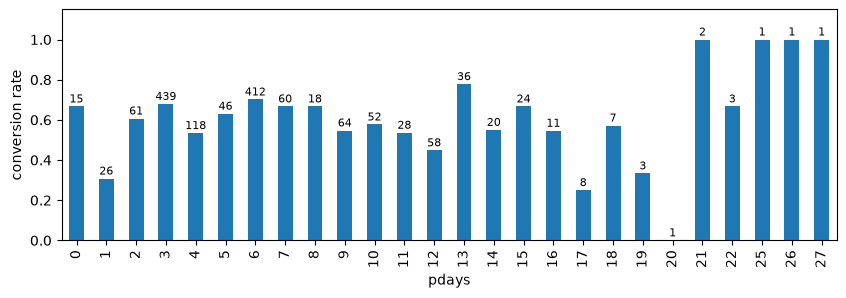

In [17]:
# Conversion by days since previous contact.

contacted = df[df['pdays'] != 999]
stats = contacted.groupby('pdays')['y_bin'].agg(['mean', 'count'])

ax = stats['mean'].plot(kind='bar', figsize=(10, 3))

for i, n in enumerate(stats['count']):
    ax.text(i, stats['mean'].iloc[i] + 0.02, str(n), ha='center', fontsize=8)

plt.ylabel('conversion rate')
plt.ylim(0, 1.15)
plt.show()

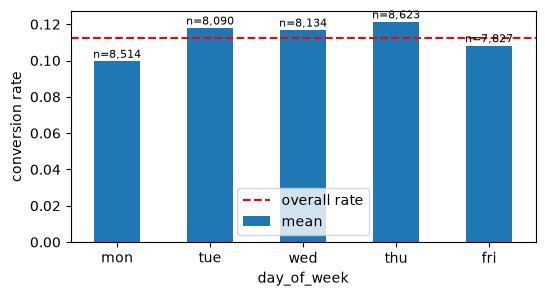

In [18]:
# Conversion by day of week.

order = ['mon', 'tue', 'wed', 'thu', 'fri']
stats = df.groupby('day_of_week')['y_bin'].agg(['mean', 'count']).reindex(order)

ax = stats['mean'].plot(kind='bar', figsize=(6, 3), rot=0)

for i, (m, n) in enumerate(zip(stats['mean'], stats['count'])):
    ax.text(i, m + 0.002, f'n={n:,}', ha='center', fontsize=8)

plt.axhline(df['y_bin'].mean(), color='red', linestyle='--', label='overall rate')
plt.ylabel('conversion rate')
plt.legend()
plt.show()

## 9. Correlations among numeric features


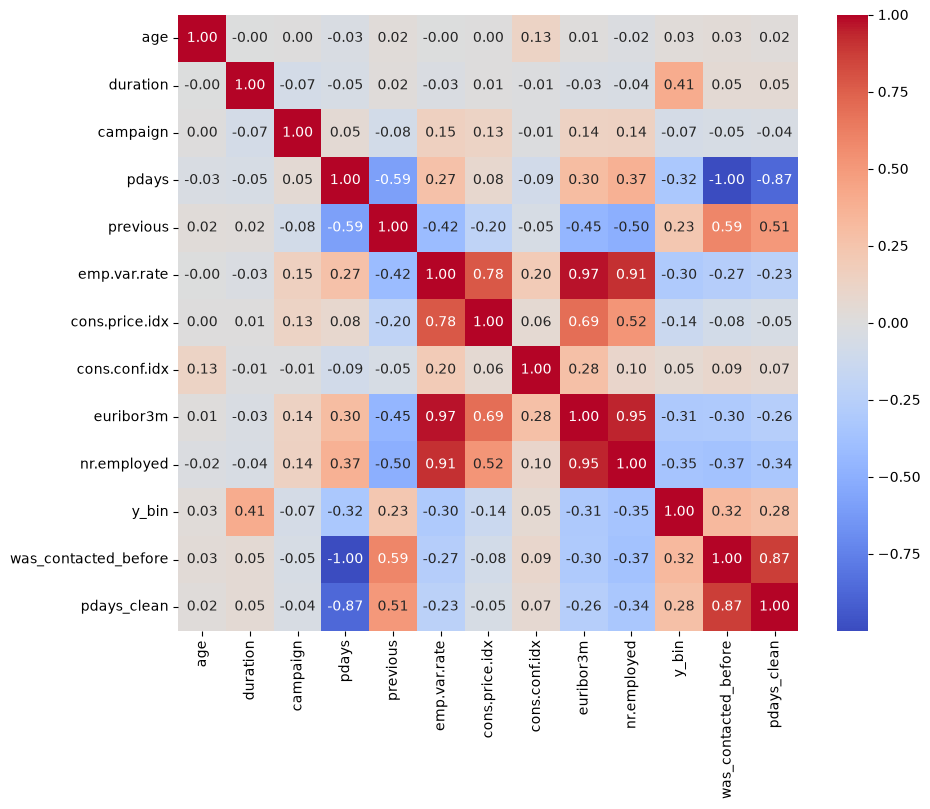

In [19]:
num_cols = df.select_dtypes(include='number').columns
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()

## 11. Age


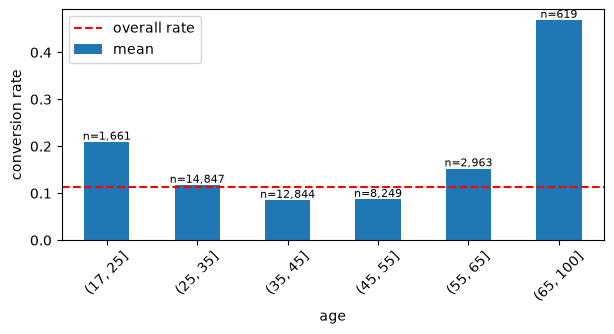

In [20]:
# Conversion by age bin.

bins = [17, 25, 35, 45, 55, 65, 100]
age_bin = pd.cut(df['age'], bins=bins)

stats = df.groupby(age_bin, observed=True)['y_bin'].agg(['mean', 'count'])

ax = stats['mean'].plot(kind='bar', figsize=(7, 3), rot=45)

for i, (m, n) in enumerate(zip(stats['mean'], stats['count'])):
    ax.text(i, m + 0.005, f'n={n:,}', ha='center', fontsize=8)

plt.axhline(df['y_bin'].mean(), color='red', linestyle='--', label='overall rate')
plt.ylabel('conversion rate')
plt.legend()
plt.show()

## 12. Conversion for categorical features

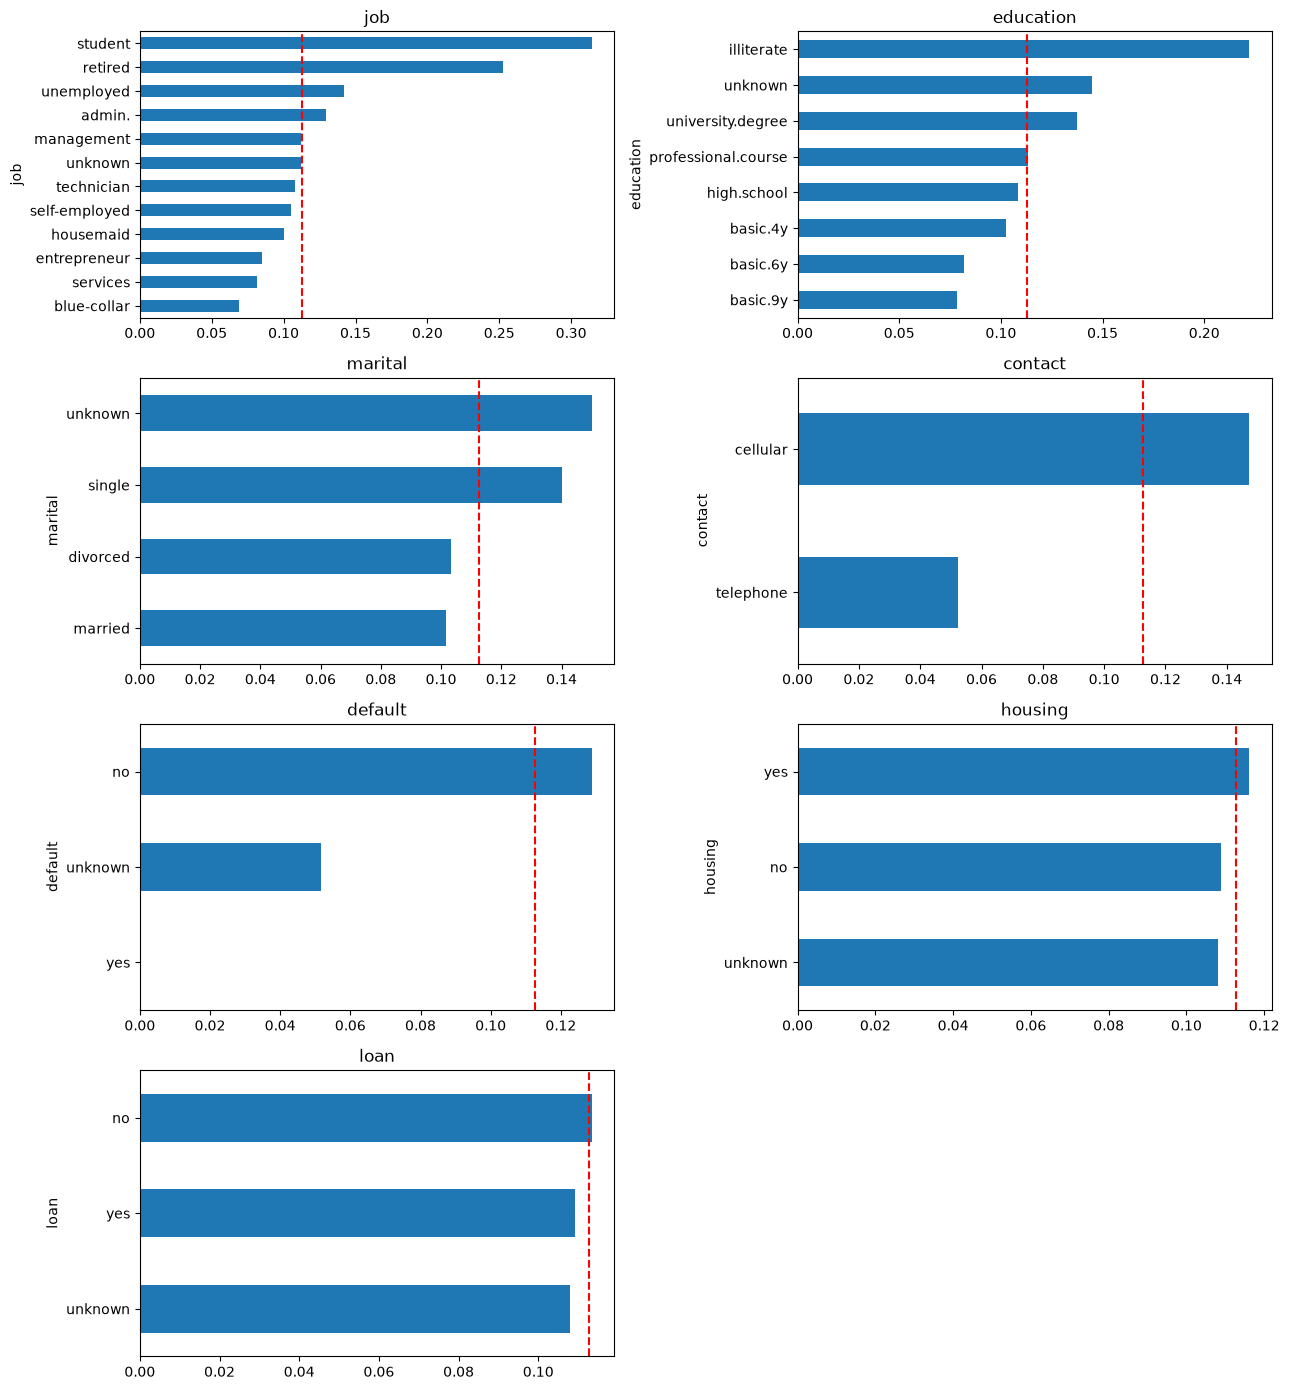

In [21]:
# Conversion by category, for all remaining categorical features.

cols = ['job', 'education', 'marital', 'contact', 'default', 'housing', 'loan']

fig, axes = plt.subplots(4, 2, figsize=(13, 14))

for ax, col in zip(axes.flat, cols):
    df.groupby(col)['y_bin'].mean().sort_values().plot(kind='barh', ax=ax)
    ax.axvline(df['y_bin'].mean(), color='red', linestyle='--')
    ax.set_title(col)

axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

## 13. Outliers in numeric features


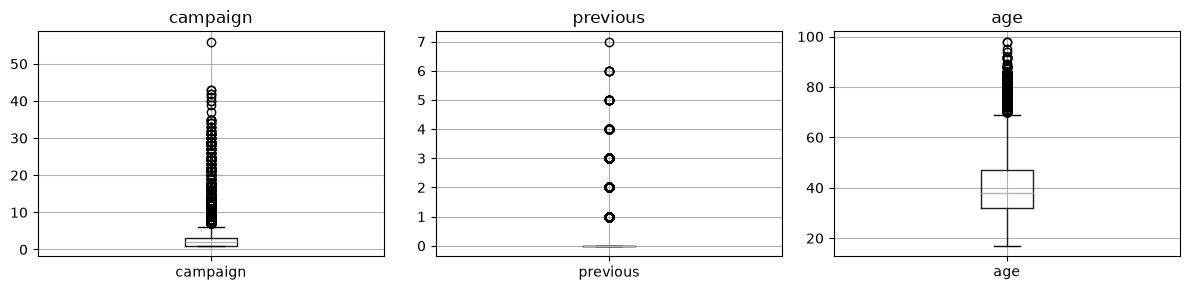

In [22]:
# Distribution of the three features with long tails.

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for ax, col in zip(axes, ['campaign', 'previous', 'age']):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [23]:
print(df[['campaign', 'previous', 'age']].describe(percentiles=[.5, .9, .99]))

           campaign      previous          age
count  41188.000000  41188.000000  41188.00000
mean       2.567593      0.172963     40.02406
std        2.770014      0.494901     10.42125
min        1.000000      0.000000     17.00000
50%        2.000000      0.000000     38.00000
90%        5.000000      1.000000     55.00000
99%       14.000000      2.000000     71.00000
max       56.000000      7.000000     98.00000


In [24]:
print(f"exact duplicates: {df.duplicated().sum()}")

exact duplicates: 12


In [25]:
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(24)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,y_bin,was_contacted_before,pdays_clean
28476,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no,0,0,-1
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no,0,0,-1
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no,0,0,-1
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no,0,0,-1
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no,0,0,-1
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no,0,0,-1
32505,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no,0,0,-1
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no,0,0,-1
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no,0,0,-1
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no,0,0,-1


In [26]:
# 12 exact duplicates, including identical call durations — a loading artefact
# rather than distinct clients. Remove.

df = df.drop_duplicates()
print(df.shape)

(41176, 24)


# Preprocessing


## 1. Split 

In [27]:
train, temp = train_test_split(df, test_size=0.30, stratify=df['y_bin'], random_state=42)

In [28]:
val, test = train_test_split(temp, test_size=0.50, stratify=temp['y_bin'], random_state=42)

In [29]:
for name, part in [('train', train), ('val', val), ('test', test)]:
    print(f"{name}: {len(part):,} rows, conversion {part['y_bin'].mean():.4f}")


train: 28,823 rows, conversion 0.1127
val: 6,176 rows, conversion 0.1127
test: 6,177 rows, conversion 0.1127


## 2. Separate features from target. 


In [30]:
DROP = ['duration', 'y', 'y_bin', 'pdays', 'pdays_clean']

X_train, y_train = train.drop(columns=DROP), train['y_bin']
X_val, y_val = val.drop(columns=DROP), val['y_bin']
X_test, y_test = test.drop(columns=DROP), test['y_bin']
print(X_train.shape, X_val.shape, X_test.shape)

(28823, 19) (6176, 19) (6177, 19)


In [31]:
X_train


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before
27506,57,admin.,married,high.school,no,yes,no,cellular,nov,fri,2,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
20991,44,blue-collar,married,basic.6y,unknown,no,no,cellular,aug,thu,1,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,0
34380,31,blue-collar,single,high.school,no,no,no,cellular,may,thu,1,1,failure,-1.8,92.893,-46.2,1.266,5099.1,0
17259,53,retired,married,professional.course,no,no,no,cellular,jul,fri,2,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0
15329,31,self-employed,single,university.degree,no,yes,no,cellular,jul,fri,2,0,nonexistent,1.4,93.918,-42.7,4.957,5228.1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6971,32,management,married,university.degree,no,yes,no,telephone,may,thu,1,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,0
8970,33,admin.,married,university.degree,no,unknown,unknown,telephone,jun,thu,1,0,nonexistent,1.4,94.465,-41.8,4.866,5228.1,0
33752,30,entrepreneur,married,university.degree,no,no,no,cellular,may,wed,1,0,nonexistent,-1.8,92.893,-46.2,1.281,5099.1,0
18503,34,technician,married,professional.course,unknown,no,no,cellular,jul,thu,1,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,0


In [32]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()

print(f"categorical ({len(cat_cols)}): {cat_cols}")
print(f"numeric ({len(num_cols)}): {num_cols}")

categorical (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
numeric (9): ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted_before']


/var/folders/dt/v_rjt_mx4k1g8dyxbm2gw8140000gn/T/ipykernel_62325/4104197311.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns.tolist()


## 3. Preprocessing pipeline for tree models

Trees split on thresholds, so scaling and skew correction have no effect. The only
required step is turning categorical strings into numbers.

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
tree_prep = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ('num', 'passthrough', num_cols),
])

X_train_tree = tree_prep.fit_transform(X_train)
X_val_tree = tree_prep.transform(X_val)

print(X_train_tree.shape)



(28823, 19)


## 4. Decision tree

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
tree = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
tree.fit(X_train_tree, y_train)

train_proba = tree.predict_proba(X_train_tree)[:, 1]
val_proba = tree.predict_proba(X_val_tree)[:, 1]

print(f"PR-AUC  train: {average_precision_score(y_train, train_proba):.4f}")
print(f"PR-AUC  val:   {average_precision_score(y_val, val_proba):.4f}")
print(f"ROC-AUC train: {roc_auc_score(y_train, train_proba):.4f}")
print(f"ROC-AUC val:   {roc_auc_score(y_val, val_proba):.4f}")
print(f"baseline:      {y_train.mean():.4f}")

PR-AUC  train: 0.4229
PR-AUC  val:   0.4231
ROC-AUC train: 0.7819
ROC-AUC val:   0.7803
baseline:      0.1127


In [35]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 5-fold CV on the training set only. 

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for depth in [3, 5, 6, 7, 8, 10]:
    t = DecisionTreeClassifier(max_depth=depth, class_weight='balanced', random_state=42)
    scores = cross_val_score(t, X_train_tree, y_train, cv=cv, scoring='average_precision')
    print(f"depth={depth:>2}  PR-AUC {scores.mean():.4f} ± {scores.std():.4f}")

depth= 3  PR-AUC 0.3661 ± 0.0110
depth= 5  PR-AUC 0.4007 ± 0.0129
depth= 6  PR-AUC 0.4134 ± 0.0146
depth= 7  PR-AUC 0.4105 ± 0.0156
depth= 8  PR-AUC 0.4083 ± 0.0154
depth=10  PR-AUC 0.3738 ± 0.0168


In [36]:
tree = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
tree.fit(X_train_tree, y_train)

tree_result = evaluate(tree, X_train_tree, y_train, X_val_tree, y_val,
                       'Decision Tree', 'max_depth=6, balanced')
pd.Series(tree_result)

model                    Decision Tree
params           max_depth=6, balanced
pr_auc_train                  0.452774
pr_auc_val                    0.431756
pr_auc_gap                    0.021018
roc_auc_train                 0.791554
roc_auc_val                   0.785282
dtype: object

## 5. XGBoost

In [37]:
from xgboost import XGBClassifier

spw = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(scale_pos_weight=spw, eval_metric='aucpr', random_state=42)
xgb.fit(X_train_tree, y_train)

xgb_result = evaluate(xgb, X_train_tree, y_train, X_val_tree, y_val,
                      'XGBoost', f'defaults, spw={spw:.2f}')
pd.Series(xgb_result)

model                       XGBoost
params           defaults, spw=7.88
pr_auc_train               0.751882
pr_auc_val                  0.41737
pr_auc_gap                 0.334512
roc_auc_train              0.942144
roc_auc_val                0.760595
dtype: object

## 6. Hyperparameter tuning: RandomizedSearchCV

Random sampling from a parameter distribution, scored by 5-fold CV on the training
set. The default XGBoost overfits heavily (gap 0.335), so the search space is built
around regularisation: shallower trees, lower learning rate, subsampling.

In [38]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
xgb_base = XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='aucpr',
    random_state=42,
)
xgb_base._estimator_type = "classifier"
param_dist = {
    'n_estimators': randint(100, 600),
    'max_depth': randint(2, 8),
    'learning_rate': uniform(0.01, 0.29),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 20),
    'gamma': uniform(0, 5),
}

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train_tree, y_train)

print(f"best CV PR-AUC: {search.best_score_:.4f}")
print(search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
best CV PR-AUC: 0.4675
{'colsample_bytree': np.float64(0.9594216754108317), 'gamma': np.float64(3.0321452982979498), 'learning_rate': np.float64(0.012667144968822599), 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 252, 'subsample': np.float64(0.6020246335384875)}


In [39]:
xgb_rs = search.best_estimator_

xgb_rs_result = evaluate(xgb_rs, X_train_tree, y_train, X_val_tree, y_val,
                         'XGBoost + RandomizedSearch',
                         f'lr=0.013, depth=7, n_est=252, gamma=3.03')
pd.Series(xgb_rs_result)


model                          XGBoost + RandomizedSearch
params           lr=0.013, depth=7, n_est=252, gamma=3.03
pr_auc_train                                     0.556818
pr_auc_val                                       0.472364
pr_auc_gap                                       0.084454
roc_auc_train                                    0.857913
roc_auc_val                                      0.803436
dtype: object

## 7. Hyperparameter tuning: Hyperopt (Bayesian optimisation)

Unlike random sampling, Bayesian optimisation builds a model of the objective
surface and concentrates sampling where improvement is likely. Same search space
and the same CV scheme, so the two methods are directly comparable.


In [40]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import numpy as np

space = {
    'n_estimators': hp.quniform('n_estimators', 100, 600, 1),
    'max_depth': hp.quniform('max_depth', 2, 8, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'min_child_weight': hp.quniform('min_child_weight', 1, 20, 1),
    'gamma': hp.uniform('gamma', 0, 5),
}

def objective(params):
    params['n_estimators'] = int(params['n_estimators'])
    params['max_depth'] = int(params['max_depth'])
    params['min_child_weight'] = int(params['min_child_weight'])

    model = XGBClassifier(
        **params,
        scale_pos_weight=spw,
        eval_metric='aucpr',
        random_state=42,
    )
    scores = cross_val_score(model, X_train_tree, y_train,
                             cv=cv, scoring='average_precision', n_jobs=-1)
    return {'loss': -scores.mean(), 'status': STATUS_OK}

trials = Trials()
best = fmin(objective, space, algo=tpe.suggest, max_evals=50,
            trials=trials, rstate=np.random.default_rng(42))

print(f"best CV PR-AUC: {-min(trials.losses()):.4f}")
print(best)

100%|██████████| 50/50 [01:11<00:00,  1.43s/trial, best loss: -0.4710577396698117] 
best CV PR-AUC: 0.4711
{'colsample_bytree': np.float64(0.6811891112198021), 'gamma': np.float64(3.7936634450050732), 'learning_rate': np.float64(0.02120202145522126), 'max_depth': np.float64(8.0), 'min_child_weight': np.float64(18.0), 'n_estimators': np.float64(353.0), 'subsample': np.float64(0.8970165968892057)}
